In [1]:
import pandas as pd
import numpy as np

# กำหนด Seed เพื่อให้สุ่มข้อมูลได้ผลเหมือนเดิมทุกครั้ง
np.random.seed(42)

# 1. สร้างวันที่ย้อนหลัง 3 ปี
# สมมติอ้างอิงจากวันที่ปัจจุบัน ย้อนไป 3 ปี
dates = pd.date_range(end='2026-06-25', periods=1095, freq='D')

# 2. สร้างฟีเจอร์สภาพอากาศ (Weather Features)
# อุณหภูมิ (มีฤดูกาล ซายน์เวฟ)
temperature = 28 + 4 * np.sin(np.arange(1095) * (2 * np.pi / 365) + np.pi/2) + np.random.normal(0, 1.5, 1095)
# ความชื้น (หน้าฝนชื้น หน้าหนาวแห้ง)
humidity = 70 + 15 * np.cos(np.arange(1095) * (2 * np.pi / 365)) + np.random.normal(0, 5, 1095)
# ความเร็วลม (ลมแรงพัดฝุ่นหาย)
wind_speed = np.random.uniform(5, 20, 1095)

# 3. สร้าง Baseline ฝุ่น PM 2.5 (ฤดูกาล: พุ่งสูงช่วงปลายปี-ต้นปี)
# ใช้ Sine wave คาบ 365 วัน พีคช่วงประมาณเดือน ม.ค. - ก.พ.
seasonality = 35 + 25 * np.cos(np.arange(1095) * (2 * np.pi / 365) - np.pi/8)

# 4. จำลองค่าฝุ่นเขตปทุมวัน (Target)
# ฝุ่นแปรผันตามฤดูกาล + ลมยิ่งแรงฝุ่นยิ่งน้อย + ความชื้นสูงฝุ่นมักจะลด + Noise
target_pm25 = seasonality - (wind_speed * 0.8) - (humidity * 0.1) + np.random.normal(0, 5, 1095)
target_pm25 = np.clip(target_pm25, 5, 150) # จำกัดค่าให้อยู่ในช่วงที่สมจริง (5 - 150)

# 5. จำลองค่าเฉลี่ยฝุ่นเขตรอบข้าง (Neighbor Average)
# เขตรอบข้างจะมีค่าฝุ่นคล้ายๆ กัน แต่มีค่าคลาดเคลื่อนนิดหน่อย
neighbor_pm25 = target_pm25 + np.random.normal(0, 3, 1095) + (wind_speed * 0.2)
neighbor_pm25 = np.clip(neighbor_pm25, 5, 150)

# 6. รวมข้อมูลลง DataFrame
df_pm25 = pd.DataFrame({
    'date': dates,
    'target_pm25': np.round(target_pm25, 1),
    'neighbor_avg_pm25': np.round(neighbor_pm25, 1),
    'temperature': np.round(temperature, 1),
    'humidity': np.round(humidity, 1),
    'wind_speed': np.round(wind_speed, 1)
})

# ตั้งค่า Index เป็นวันที่
df_pm25.set_index('date', inplace=True)

# 7. บันทึกเป็นไฟล์ CSV (นำไปใช้ต่อในขั้นตอน Modeling)
df_pm25.to_csv('pm25_pathumwan_spatial_3yrs.csv')

print("✅ สร้าง Dataset จำลอง 3 ปี สำเร็จ! รูปแบบข้อมูล 5 แถวแรก:")
print(df_pm25.head())

✅ สร้าง Dataset จำลอง 3 ปี สำเร็จ! รูปแบบข้อมูล 5 แถวแรก:
            target_pm25  neighbor_avg_pm25  temperature  humidity  wind_speed
date                                                                         
2023-06-27         35.9               40.7         32.7      84.6        19.4
2023-06-28         42.1               44.3         31.8      85.4         8.0
2023-06-29         42.3               50.0         33.0      75.0        19.3
2023-06-30         40.8               39.2         34.3      89.6        19.9
2023-07-01         44.8               48.3         31.6      86.7        15.7


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. สมมติว่าเราโหลดข้อมูลจากไฟล์ CSV ที่สร้างไว้ในสเต็ปที่แล้ว
df = pd.read_csv('pm25_pathumwan_spatial_3yrs.csv', index_col='date', parse_dates=True)

# 2. แบ่งข้อมูล Train / Test ตามลำดับเวลา (Chronological Split)
# ใช้ 80% สำหรับ Train (ประมาณ 2.4 ปี) และ 20% สำหรับ Test
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size].copy()
test_data = df.iloc[train_size:].copy()

print(f"จำนวนวันสำหรับ Train: {len(train_data)} วัน")
print(f"จำนวนวันสำหรับ Test: {len(test_data)} วัน")

# 3. การทำ Data Scaling
# เคล็ดลับ: ต้องสร้าง Scaler แยกสำหรับ X (Features) และ Y (Target)
# เพื่อให้ง่ายต่อการแปลงค่ากลับ (Inverse Transform) ไปเป็นหน่วยไมโครกรัม/ลูกบาศก์เมตร ในตอนจบ
feature_cols = ['target_pm25', 'neighbor_avg_pm25', 'temperature', 'humidity', 'wind_speed']
target_col = ['target_pm25']

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit และ Transform ข้อมูล Train
train_x_scaled = scaler_x.fit_transform(train_data[feature_cols])
train_y_scaled = scaler_y.fit_transform(train_data[target_col])

# Transform ข้อมูล Test อย่างเดียว (ห้าม fit ใหม่เด็ดขาด เพื่อป้องกัน Data Leakage)
test_x_scaled = scaler_x.transform(test_data[feature_cols])
test_y_scaled = scaler_y.transform(test_data[target_col])

# 4. สร้างฟังก์ชันจัดกลุ่มข้อมูลเป็น Sequences (Sliding Window) สำหรับ LSTM/GRU
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # เก็บข้อมูล x ย้อนหลังตามจำนวน time_steps
        Xs.append(X[i:(i + time_steps)])
        # เก็บข้อมูล y (Target) ของวันถัดไป
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# กำหนด Look-back window: ใช้ข้อมูลอดีต 7 วัน พยากรณ์วันพรุ่งนี้
TIME_STEPS = 7

X_train, y_train = create_sequences(train_x_scaled, train_y_scaled, TIME_STEPS)
X_test, y_test = create_sequences(test_x_scaled, test_y_scaled, TIME_STEPS)

# 5. ตรวจสอบมิติของข้อมูล (Shape) ที่พร้อมเข้าโมเดล
print("\n--- รูปร่างของข้อมูล (Data Shape) ---")
print(f"X_train shape: {X_train.shape} -> (Samples, Time Steps, Features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

จำนวนวันสำหรับ Train: 876 วัน
จำนวนวันสำหรับ Test: 219 วัน

--- รูปร่างของข้อมูล (Data Shape) ---
X_train shape: (869, 7, 5) -> (Samples, Time Steps, Features)
y_train shape: (869, 1)
X_test shape:  (212, 7, 5)
y_test shape:  (212, 1)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. การเตรียมโมเดล ARIMA (Statistical Baseline)
# ---------------------------------------------------------
print("Training ARIMA Model...")
# ARIMA มักจะใช้แค่แกน Y (Univariate) ในการทำนายเป็นหลัก
# ในที่นี้เราจะใช้ข้อมูลฝุ่น target_pm25 อย่างเดียว
train_arima_y = train_data['target_pm25'].values
test_arima_y = test_data['target_pm25'].values

# กำหนดพารามิเตอร์ (p, d, q) แบบง่ายๆ (ในงานจริงควรทำ Grid Search หาค่า AIC ที่ต่ำสุด)
# สมมติใช้ (5, 1, 0) คือดูอดีต 5 วัน และทำ differencing 1 ครั้ง
arima_model = ARIMA(train_arima_y, order=(5, 1, 0))
arima_fit = arima_model.fit()

# ทำนายค่าสำหรับช่วง Test
arima_predictions = arima_fit.forecast(steps=len(test_arima_y))

# ---------------------------------------------------------
# 2. การกำหนดสถาปัตยกรรมสำหรับ Deep Learning (LSTM & GRU)
# ---------------------------------------------------------
# กำหนดค่าพารามิเตอร์ของ Neural Network ให้เหมือนกันเป๊ะเพื่อเปรียบเทียบ
epochs = 50
batch_size = 32
input_shape = (X_train.shape[1], X_train.shape[2]) # (7 Time Steps, 5 Features)

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2)) # ป้องกัน Overfitting
    model.add(Dense(1)) # Output 1 ค่า (ค่าฝุ่นที่ทำนาย)
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ---------------------------------------------------------
# 3. ฝึกสอนโมเดล (Training)
# ---------------------------------------------------------
print("Training LSTM Model...")
lstm_model = build_lstm_model(input_shape)
history_lstm = lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                              validation_split=0.1, verbose=0) # ปิด verbose เพื่อลดข้อความตอนเทรน

print("Training GRU Model...")
gru_model = build_gru_model(input_shape)
history_gru = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                            validation_split=0.1, verbose=0)

# ---------------------------------------------------------
# 4. การทำนาย (Prediction) และแปลงสเกลกลับ (Inverse Scaling)
# ---------------------------------------------------------
# โมเดล Deep Learning พ่นค่าสเกล 0-1 ออกมา ต้องแปลงกลับเป็นไมโครกรัม/ลบ.ม.
lstm_pred_scaled = lstm_model.predict(X_test)
gru_pred_scaled = gru_model.predict(X_test)

# ใช้ scaler_y ที่เราแยกไว้แต่แรก แปลงค่ากลับ
lstm_predictions = scaler_y.inverse_transform(lstm_pred_scaled)
gru_predictions = scaler_y.inverse_transform(gru_pred_scaled)
actual_y = scaler_y.inverse_transform(y_test)

# ปรับ ARIMA เล็กน้อยให้ขนาด (Shape) ตรงกับ Deep Learning
# (ตัด 7 วันแรกออก เพราะ LSTM/GRU ใช้ 7 วันนั้นเป็น Look-back window เริ่มต้น)
arima_predictions = arima_predictions[TIME_STEPS:]
actual_y_arima = test_arima_y[TIME_STEPS:]

# ---------------------------------------------------------
# 5. การประเมินผล (Evaluation)
# ---------------------------------------------------------
def evaluate_model(actual, pred, model_name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.2f} µg/m³")
    print(f"MAE:  {mae:.2f} µg/m³\n")

evaluate_model(actual_y_arima, arima_predictions, "ARIMA")
evaluate_model(actual_y, lstm_predictions, "LSTM")
evaluate_model(actual_y, gru_predictions, "GRU")

Training ARIMA Model...
Training LSTM Model...
Training GRU Model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
--- ARIMA ---
RMSE: 14.04 µg/m³
MAE:  9.17 µg/m³

--- LSTM ---
RMSE: 4.24 µg/m³
MAE:  2.86 µg/m³

--- GRU ---
RMSE: 4.37 µg/m³
MAE:  2.83 µg/m³



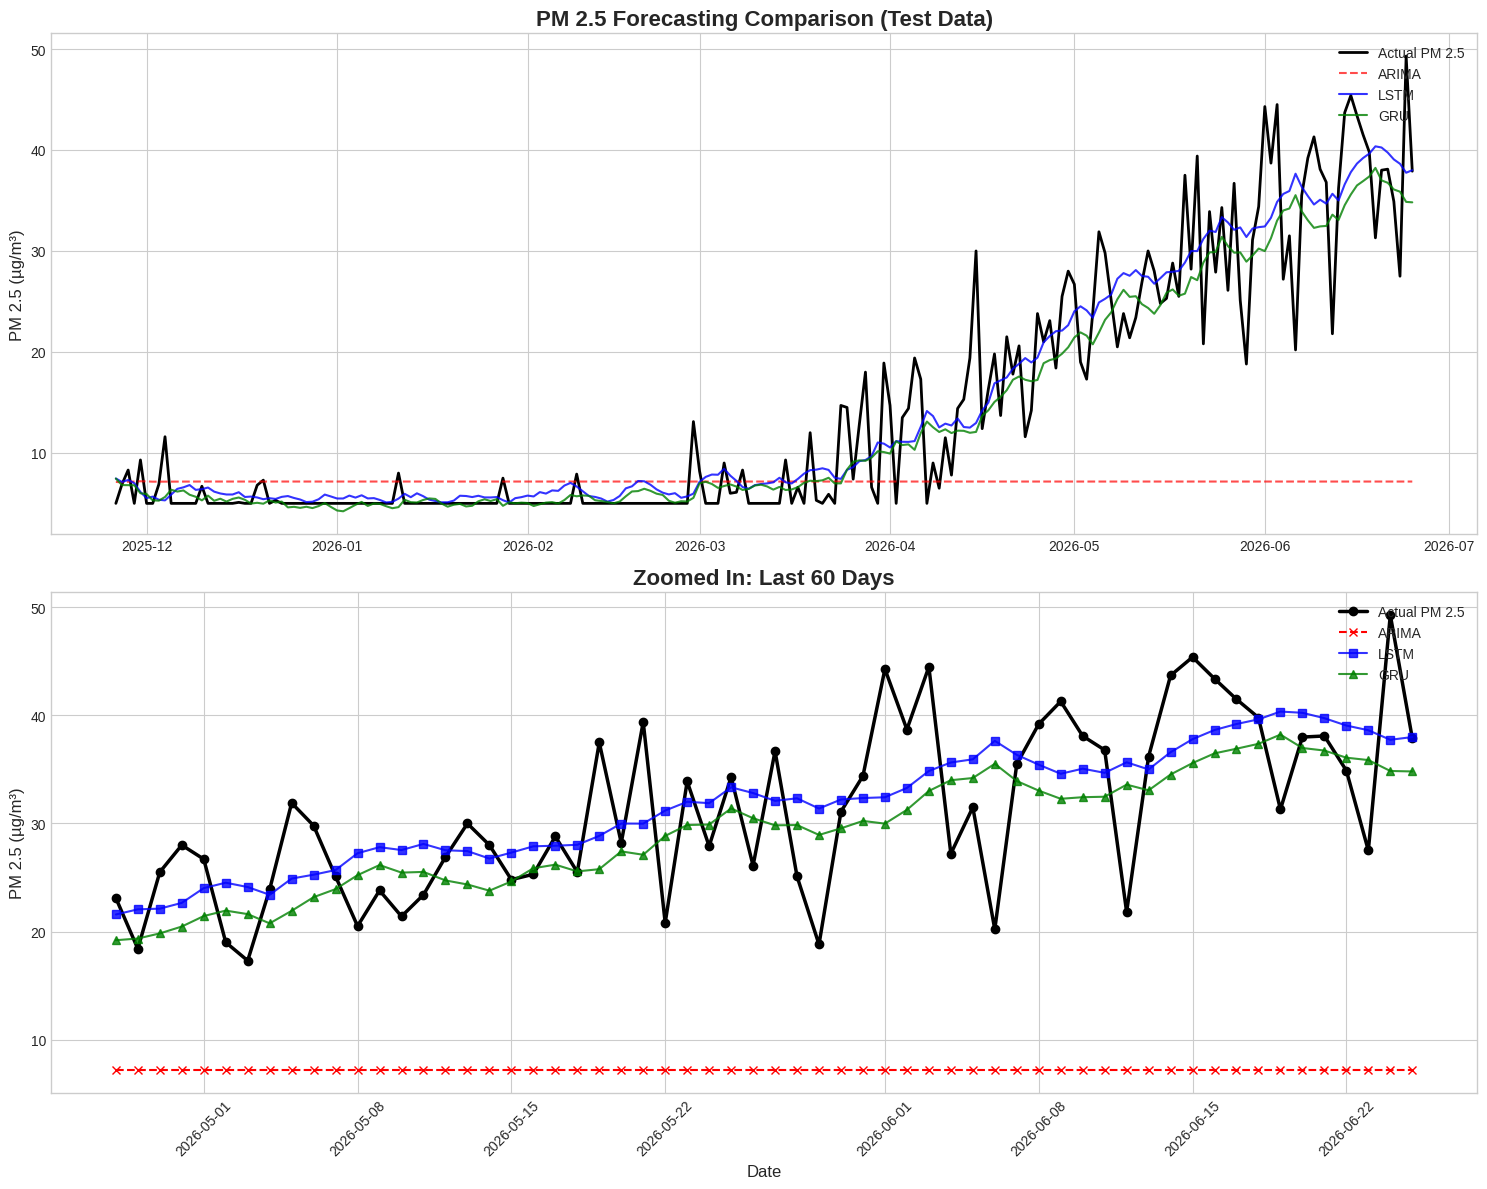

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ดึงวันที่ของชุดข้อมูล Test มาใช้เป็นแกน X (ตัด 7 วันแรกออกตาม Look-back window)
test_dates = test_data.index[TIME_STEPS:]

# ตั้งค่าสไตล์ของกราฟให้ดูเป็นมืออาชีพ
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# ---------------------------------------------------------
# กราฟที่ 1: เปรียบเทียบภาพรวม (Overall Comparison)
# ---------------------------------------------------------
ax1.plot(test_dates, actual_y, label='Actual PM 2.5', color='black', linewidth=2)
ax1.plot(test_dates, arima_predictions, label='ARIMA', color='red', linestyle='--', alpha=0.7)
ax1.plot(test_dates, lstm_predictions, label='LSTM', color='blue', alpha=0.8)
ax1.plot(test_dates, gru_predictions, label='GRU', color='green', alpha=0.8)

ax1.set_title('PM 2.5 Forecasting Comparison (Test Data)', fontsize=16, fontweight='bold')
ax1.set_ylabel('PM 2.5 (µg/m³)', fontsize=12)
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # แสดงผลวันที่แบบ ปี-เดือน

# ---------------------------------------------------------
# กราฟที่ 2: ซูมดูข้อมูล 60 วันล่าสุด (Zoom-in Last 60 Days)
# ---------------------------------------------------------
zoom_days = 60
ax2.plot(test_dates[-zoom_days:], actual_y[-zoom_days:], label='Actual PM 2.5', color='black', linewidth=2.5, marker='o')
ax2.plot(test_dates[-zoom_days:], arima_predictions[-zoom_days:], label='ARIMA', color='red', linestyle='--', marker='x')
ax2.plot(test_dates[-zoom_days:], lstm_predictions[-zoom_days:], label='LSTM', color='blue', marker='s', alpha=0.8)
ax2.plot(test_dates[-zoom_days:], gru_predictions[-zoom_days:], label='GRU', color='green', marker='^', alpha=0.8)

ax2.set_title(f'Zoomed In: Last {zoom_days} Days', fontsize=16, fontweight='bold')
ax2.set_ylabel('PM 2.5 (µg/m³)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# ---------------------------------------------------------
# 6. ระบบแจ้งเตือนอัตโนมัติ (Automated Alert System)
# ---------------------------------------------------------

def generate_pm25_alert(predicted_value, date_target):
    print(f"📊 ผลการพยากรณ์ค่าฝุ่น PM 2.5 ล่วงหน้าสำหรับวันที่: {date_target}")
    print(f"ค่าที่ทำนายได้: {predicted_value:.2f} µg/m³\n")

    # อ้างอิงเกณฑ์ (สมมติ) ของกรมควบคุมมลพิษ หรือ WHO
    if predicted_value <= 25.0:
        status = "🟢 ดีมาก (Excellent)"
        action = "อากาศดีมาก เหมาะสำหรับการทำกิจกรรมกลางแจ้งและการท่องเที่ยว"
    elif predicted_value <= 50.0:
        status = "🟡 ปานกลาง (Moderate)"
        action = "ประชาชนทั่วไปทำกิจกรรมกลางแจ้งได้ กลุ่มเสี่ยงควรเฝ้าระวังอาการ"
    elif predicted_value <= 75.0:
        status = "🟠 เริ่มมีผลกระทบต่อสุขภาพ (Unhealthy for Sensitive Groups)"
        action = "⚠️ แจ้งเตือน: ควรงดกิจกรรมกลางแจ้งที่ใช้แรงมาก กลุ่มเสี่ยงควรใส่หน้ากาก N95"
    else:
        status = "🔴 มีผลกระทบต่อสุขภาพมาก (Very Unhealthy / Hazardous)"
        action = "🚨 แจ้งเตือนฉุกเฉิน: งดกิจกรรมกลางแจ้งทุกชนิด ทุกคนต้องสวมหน้ากาก N95 และอยู่ในอาคาร"

    print(f"สถานะ: {status}")
    print(f"ข้อแนะนำ: {action}")
    print("-" * 60)

# สมมติว่าเราดึงค่าพยากรณ์ของ "วันสุดท้าย" ใน Test Set มาใช้งาน
# (ในงานจริงคือการดึงข้อมูล 7 วันล่าสุด ณ วันนี้ เพื่อทำนายพรุ่งนี้)
tomorrow_date = test_dates[-1].strftime('%Y-%m-%d')
tomorrow_prediction = lstm_predictions[-1][0] # ดึงค่าจากโมเดล LSTM

# รันระบบแจ้งเตือน
generate_pm25_alert(tomorrow_prediction, tomorrow_date)

📊 ผลการพยากรณ์ค่าฝุ่น PM 2.5 ล่วงหน้าสำหรับวันที่: 2026-06-25
ค่าที่ทำนายได้: 38.00 µg/m³

สถานะ: 🟡 ปานกลาง (Moderate)
ข้อแนะนำ: ประชาชนทั่วไปทำกิจกรรมกลางแจ้งได้ กลุ่มเสี่ยงควรเฝ้าระวังอาการ
------------------------------------------------------------
